# 1. Exploratory Data Analysis (EDA)

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 1.1 Load Dataset

In [40]:
target_df = pd.read_csv('../dataset/musae_git_target.csv')
print(f"Target data shape: {target_df.shape}")
target_df.head()

Target data shape: (37700, 3)


,id,name,ml_target
0,0,Eiryyy,0
1,1,shawflying,0
2,2,JpMCarrilho,1
3,3,SuhwanCha,0
4,4,sunilangadi2,1


In [41]:
with open('../dataset/musae_git_features.json', 'r') as f:
    features_json = json.load(f)

print(f"Number of users in features: {len(features_json)}")

Number of users in features: 37700


In [42]:
all_features = set()
for user_features in features_json.values():
    all_features.update(user_features)

num_features = max(all_features) + 1
print(f"Total unique feature indices: {len(all_features)}")
print(f"Max feature index: {num_features - 1}")

Total unique feature indices: 4005
Max feature index: 4004


In [43]:
n_users = len(features_json)
feature_matrix = np.zeros((n_users, num_features), dtype=np.int8)

for user_id, user_features in features_json.items():
    idx = int(user_id)
    feature_matrix[idx, user_features] = 1

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Memory usage: {feature_matrix.nbytes / 1024 / 1024:.2f} MB")

Feature matrix shape: (37700, 4005)
Memory usage: 143.99 MB


In [44]:
feature_cols = [f'feat_{i}' for i in range(num_features)]
df = pd.DataFrame(feature_matrix, columns=feature_cols)

df['id'] = target_df['id']
df['name'] = target_df['name']
df['ml_target'] = target_df['ml_target']

print(f"Final DataFrame shape: {df.shape}")
df.head()

Final DataFrame shape: (37700, 4008)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_3998,feat_3999,feat_4000,feat_4001,feat_4002,feat_4003,feat_4004,id,name,ml_target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Eiryyy,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,shawflying,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,JpMCarrilho,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,3,SuhwanCha,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,4,sunilangadi2,1


## 1.2 Basic Dataset Statistics

In [45]:
print(f"Number of observations: {len(df):,}")
print(f"Number of features: {num_features:,}")
print(f"Number of numerical variables: {num_features}")
print(f"Number of categorical variables: 0")

Number of observations: 37,700
Number of features: 4,005
Number of numerical variables: 4005
Number of categorical variables: 0


In [46]:
feature_sums = feature_matrix.sum(axis=0)
features_per_user = feature_matrix.sum(axis=1)

print(f"Average features per user: {features_per_user.mean():.2f}")
print(f"Min features per user: {features_per_user.min()}")
print(f"Max features per user: {features_per_user.max()}")
print(f"\nAverage users per feature: {feature_sums.mean():.2f}")
print(f"Features with 0 users: {(feature_sums == 0).sum()}")
print(f"Sparsity: {100 * (1 - feature_matrix.sum() / feature_matrix.size):.2f}%")

Average features per user: 18.31
Min features per user: 8
Max features per user: 42

Average users per feature: 172.37
Features with 0 users: 0
Sparsity: 99.54%


In [47]:
summary_table = pd.DataFrame({
    'Category': ['Total Features', 'Binary Features (0/1)', 'Categorical Features', 
                 'Target Variable', 'Identifier Columns'],
    'Count': [num_features, num_features, 0, 1, 2],
    'Description': ['All features from user profiles', 'Sparse binary encoding of profile attributes',
                   'None - all features are binary', 'ml_target (0=web, 1=ML)', 'id, name']
})
print(summary_table.to_string(index=False))

             Category  Count                                  Description
       Total Features   4005              All features from user profiles
Binary Features (0/1)   4005 Sparse binary encoding of profile attributes
 Categorical Features      0               None - all features are binary
      Target Variable      1                      ml_target (0=web, 1=ML)
   Identifier Columns      2                                     id, name


## 1.3 Target Variable Analysis

In [48]:
class_counts = df['ml_target'].value_counts().sort_index()
class_props = df['ml_target'].value_counts(normalize=True).sort_index()

class_table = pd.DataFrame({
    'Class': ['Web Developer (0)', 'ML Developer (1)'],
    'Count': class_counts.values,
    'Proportion': [f'{p:.2%}' for p in class_props.values]
})

minority_prop = class_props.min()
if minority_prop < 0.15:
    print(f"\n⚠️ WARNING: Class imbalance detected! Minority class: {minority_prop:.2%}")
    print("Resampling techniques may be needed.")
else:
    print(f"\nClasses are reasonably balanced (minority: {minority_prop:.2%})")


Classes are reasonably balanced (minority: 25.83%)


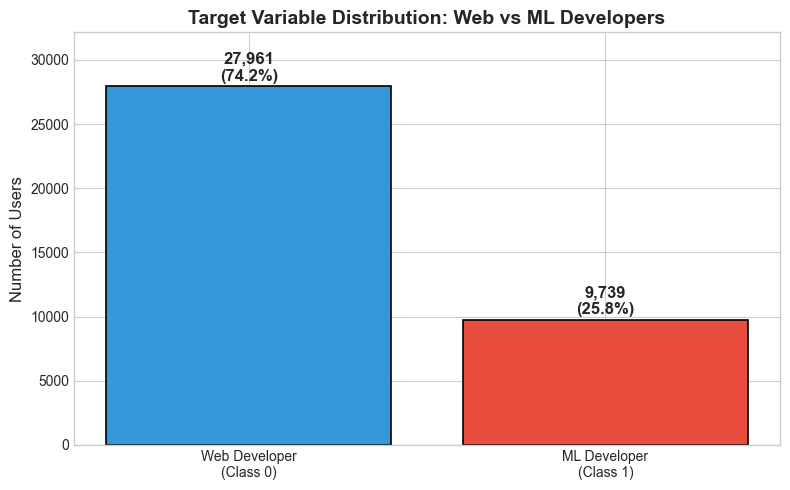

Saved: class_distribution.png


In [49]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#3498db', '#e74c3c']
bars = ax.bar(['Web Developer\n(Class 0)', 'ML Developer\n(Class 1)'], 
              class_counts.values, color=colors, edgecolor='black', linewidth=1.2)

for bar, count, prop in zip(bars, class_counts.values, class_props.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f'{count:,}\n({prop:.1%})', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title('Target Variable Distribution: Web vs ML Developers', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(class_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

## 1.4 Feature Distribution Analysis (Class Separability)

In [50]:
web_mask = df['ml_target'] == 0
ml_mask = df['ml_target'] == 1

web_means = feature_matrix[web_mask].mean(axis=0)
ml_means = feature_matrix[ml_mask].mean(axis=0)

mean_diff = np.abs(web_means - ml_means)
top_features_idx = np.argsort(mean_diff)[-10:][::-1]

for i, feat_idx in enumerate(top_features_idx):
    print(f"{i+1}. Feature {feat_idx}: Web={web_means[feat_idx]:.4f}, ML={ml_means[feat_idx]:.4f}, Diff={mean_diff[feat_idx]:.4f}")

1. Feature 1793: Web=0.0686, ML=0.5630, Diff=0.4944
2. Feature 2947: Web=0.0139, ML=0.2758, Diff=0.2619
3. Feature 1663: Web=0.2104, ML=0.0421, Diff=0.1683
4. Feature 1001: Web=0.2501, ML=0.0868, Diff=0.1633
5. Feature 3773: Web=0.2997, ML=0.4461, Diff=0.1464
6. Feature 1768: Web=0.0247, ML=0.1659, Diff=0.1412
7. Feature 3214: Web=0.2086, ML=0.0677, Diff=0.1409
8. Feature 1145: Web=0.0191, ML=0.1303, Diff=0.1112
9. Feature 2461: Web=0.0249, ML=0.1250, Diff=0.1000
10. Feature 3311: Web=0.0114, ML=0.1106, Diff=0.0992


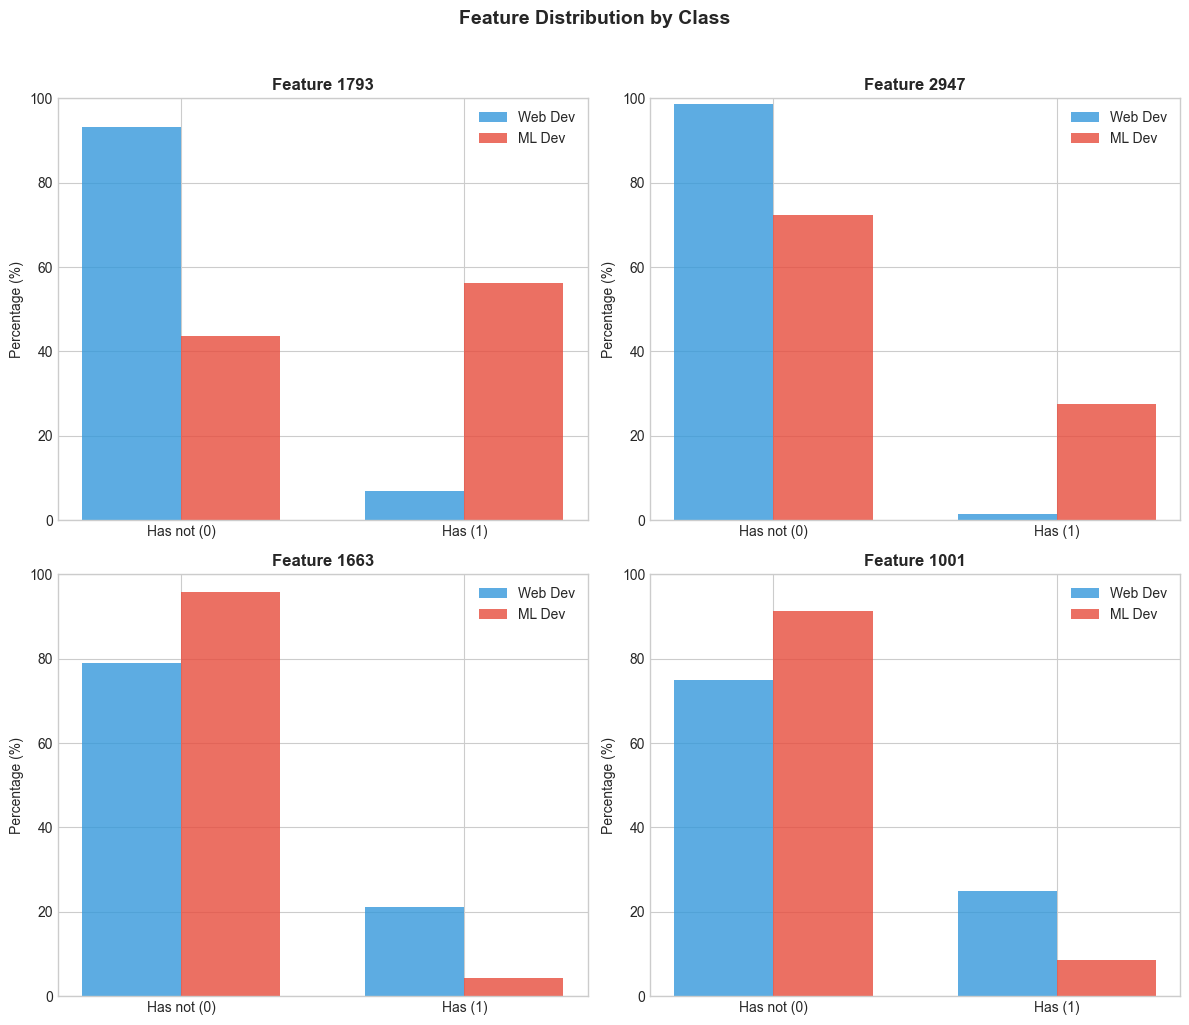

Saved: feature_distribution_by_class.png


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (ax, feat_idx) in enumerate(zip(axes.flatten(), top_features_idx[:4])):
    web_vals = feature_matrix[web_mask, feat_idx]
    ml_vals = feature_matrix[ml_mask, feat_idx]
    
    web_pct = [100 * (web_vals == 0).mean(), 100 * (web_vals == 1).mean()]
    ml_pct = [100 * (ml_vals == 0).mean(), 100 * (ml_vals == 1).mean()]
    
    x = np.arange(2)
    width = 0.35
    
    ax.bar(x - width/2, web_pct, width, label='Web Dev', color='#3498db', alpha=0.8)
    ax.bar(x + width/2, ml_pct, width, label='ML Dev', color='#e74c3c', alpha=0.8)
    
    ax.set_ylabel('Percentage (%)')
    ax.set_title(f'Feature {feat_idx}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Has not (0)', 'Has (1)'])
    ax.legend()
    ax.set_ylim(0, 100)

plt.suptitle('Feature Distribution by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distribution_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_distribution_by_class.png")

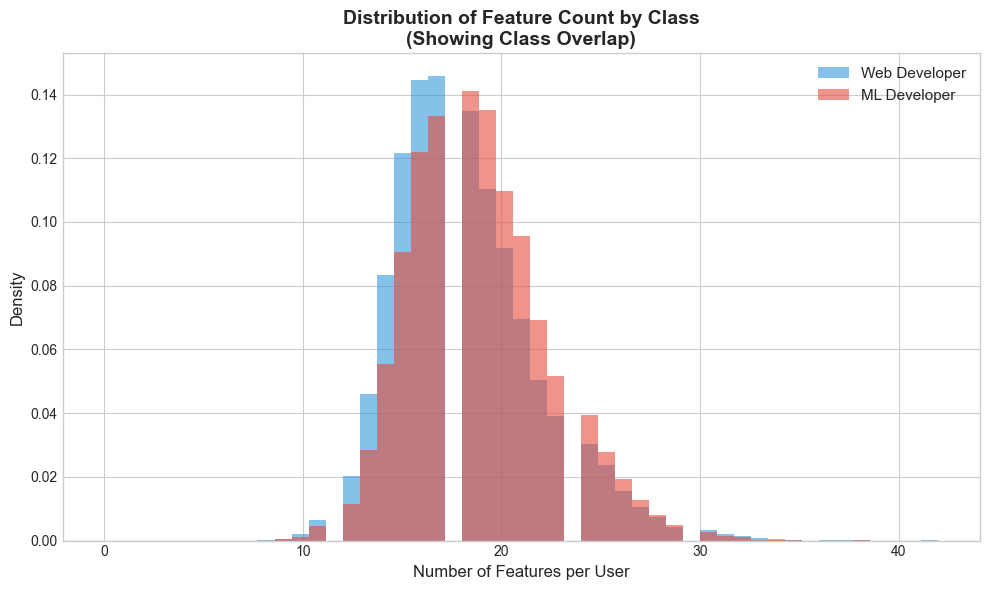

Saved: feature_count_overlap.png


In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

web_features_count = feature_matrix[web_mask].sum(axis=1)
ml_features_count = feature_matrix[ml_mask].sum(axis=1)

bins = np.linspace(0, max(features_per_user), 50)
ax.hist(web_features_count, bins=bins, alpha=0.6, label='Web Developer', color='#3498db', density=True)
ax.hist(ml_features_count, bins=bins, alpha=0.6, label='ML Developer', color='#e74c3c', density=True)

ax.set_xlabel('Number of Features per User', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Feature Count by Class\n(Showing Class Overlap)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('feature_count_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_count_overlap.png")

In [53]:
sample_size = min(5000, len(df))
sample_idx = np.random.choice(len(df), sample_size, replace=False)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(feature_matrix[sample_idx])
y_sample = df['ml_target'].iloc[sample_idx].values

print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

Explained variance ratio: PC1=4.00%, PC2=2.70%


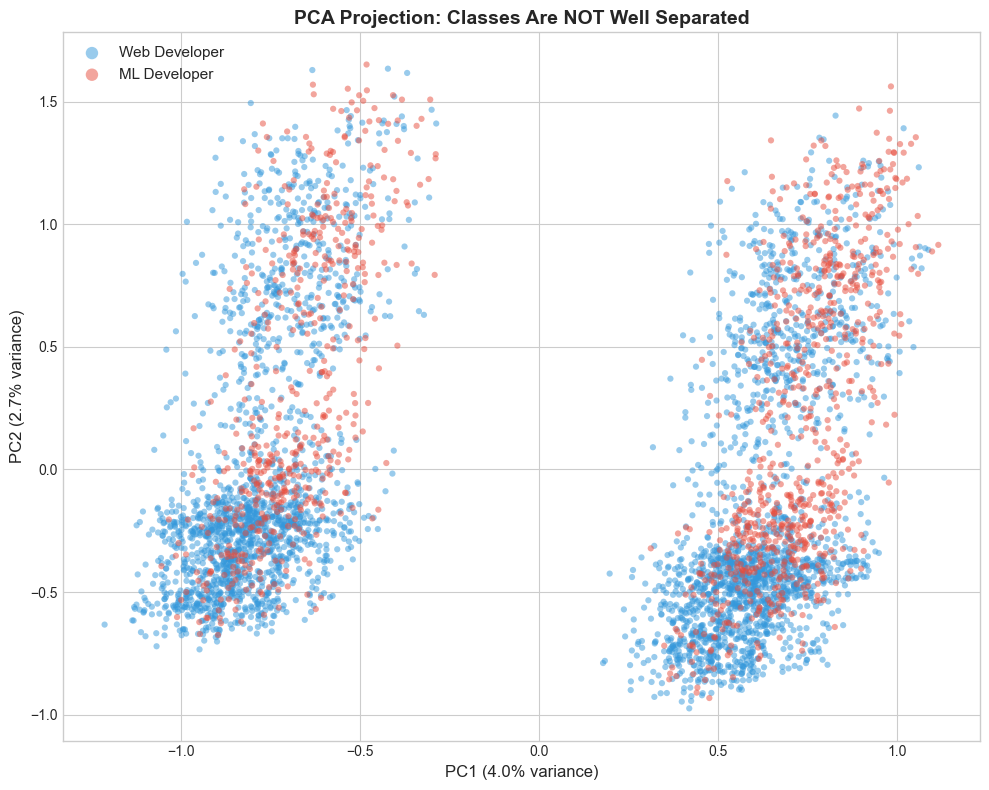

Saved: pca_class_overlap.png


In [54]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#3498db', '#e74c3c']
labels = ['Web Developer', 'ML Developer']

for class_val in [0, 1]:
    mask = y_sample == class_val
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colors[class_val], label=labels[class_val], 
               alpha=0.5, s=20, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA Projection: Classes Are NOT Well Separated', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=2)

plt.tight_layout()
plt.savefig('pca_class_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pca_class_overlap.png")

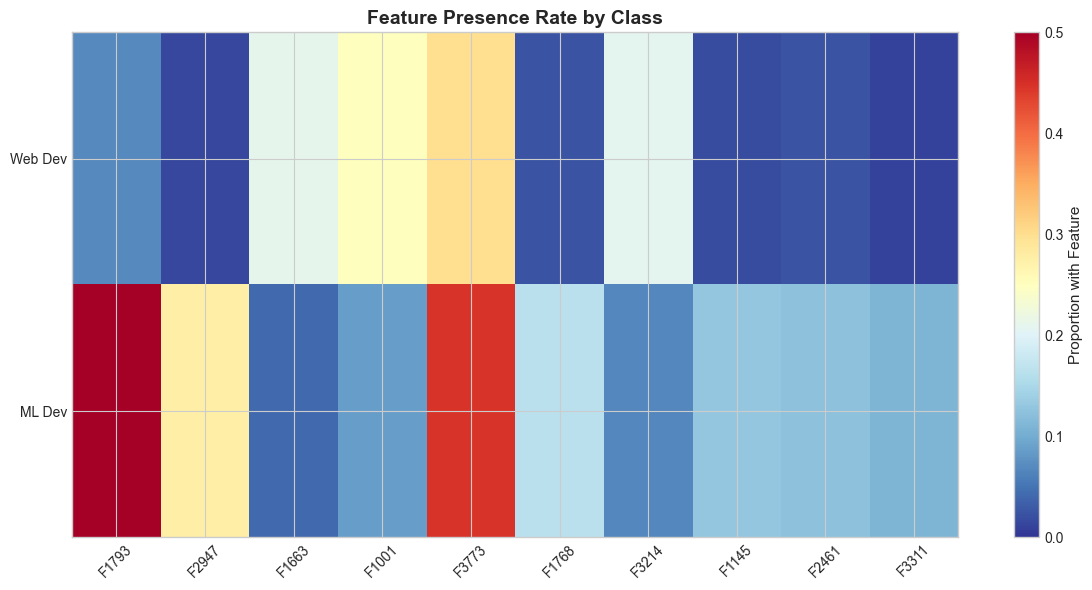

Saved: feature_heatmap.png


In [55]:
fig, ax = plt.subplots(figsize=(12, 6))

top20_idx = top_features_idx[:10].tolist() + np.argsort(mean_diff)[-20:-10][::-1].tolist()
heatmap_data = np.array([[web_means[i], ml_means[i]] for i in top20_idx[:10]])

im = ax.imshow(heatmap_data.T, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=0.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'F{i}' for i in top20_idx[:10]], rotation=45)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Web Dev', 'ML Dev'])
ax.set_title('Feature Presence Rate by Class', fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Proportion with Feature', fontsize=11)

plt.tight_layout()
plt.savefig('feature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_heatmap.png")

## 1.5 Summary

In [56]:
print(f"""
Observations: {len(df):,} GitHub users
Features: {num_features:,} binary features (sparse encoding)
Feature sparsity: {100 * (1 - feature_matrix.sum() / feature_matrix.size):.1f}%
Average features per user: {features_per_user.mean():.1f}

Class 0 (Web Developer): {class_counts[0]:,} ({class_props[0]:.1%})
Class 1 (ML Developer): {class_counts[1]:,} ({class_props[1]:.1%})
""")


Observations: 37,700 GitHub users
Features: 4,005 binary features (sparse encoding)
Feature sparsity: 99.5%
Average features per user: 18.3

Class 0 (Web Developer): 27,961 (74.2%)
Class 1 (ML Developer): 9,739 (25.8%)



In [57]:
import os
os.makedirs('data', exist_ok=True)

df_save = df[['id', 'name'] + feature_cols + ['ml_target']]
df_save.to_csv('data/matrix.csv', index=False)
print(f"Saved: data/matrix.csv ({df_save.shape[0]:,} rows, {df_save.shape[1]:,} columns)")

Saved: data/matrix.csv (37,700 rows, 4,008 columns)
